In [1]:
import tensorflow as tf

# Konfigurasi untuk menggunakan GPU Lokal
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # Mengaktifkan memory growth
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"Ditemukan {len(gpus)} GPU(s) lokal.")
    except RuntimeError as e:
        print(e)
else:
    print("PERINGATAN: GPU tidak ditemukan! Pelatihan akan berjalan di CPU.")

I0000 00:00:1778804220.292518    7062 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778804220.584995    7062 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778804222.584634    7062 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Ditemukan 1 GPU(s) lokal.


In [2]:
import os
import numpy as np
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight

IMG_SIZE = 224
BATCH_SIZE = 64
NUM_CLASSES = 7
TRAIN_DIR = 'dataset_rafdb/train'
TEST_DIR = 'dataset_rafdb/test'

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE, label_mode='categorical', shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR, image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE, label_mode='categorical', shuffle=False
)

class_names = sorted(os.listdir(TRAIN_DIR))
y_train = []
for i, c in enumerate(class_names):
    count = len(os.listdir(os.path.join(TRAIN_DIR, c)))
    y_train.extend([i] * count)
y_train = np.array(y_train)

class_weights_arr = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights_arr)}

print("Class Names:", class_names)
print("Class Weights:", class_weight_dict)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

Found 12271 files belonging to 7 classes.


I0000 00:00:1778804226.015774    7062 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5563 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Found 3068 files belonging to 7 classes.
Class Names: ['1', '2', '3', '4', '5', '6', '7']
Class Weights: {0: np.float64(1.3589147286821706), 1: np.float64(6.238434163701068), 2: np.float64(2.4449093444909344), 3: np.float64(0.3673512154233026), 4: np.float64(0.884460141271443), 5: np.float64(2.4865248226950354), 6: np.float64(0.6945324881141046)}


In [3]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomContrast, RandomZoom, Rescaling
from tensorflow.keras.models import Model, Sequential

data_augmentation = Sequential([
    Rescaling(1./255),
    RandomFlip("horizontal"),
    RandomRotation(factor=0.15),
    RandomContrast(factor=0.2),
    RandomZoom(height_factor=0.1, width_factor=0.1)
], name="data_augmentation")

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False # Freeze the base for Phase 1

inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
predictions = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=inputs, outputs=predictions)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │         8,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,266,951 (8.65 MB)

 Trainable params: 8,967 (35.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [4]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.losses import CategoricalFocalCrossentropy

# Advanced Optimizations: Focal Loss + Label Smoothing
# Focal loss memaksa model fokus pada 'hard examples' (kelas minoritas yang sulit).
# Label smoothing=0.1 membuat target probabilitas tidak mutlak 1.0/0.0, mencegah overconfidence.
loss_fn = CategoricalFocalCrossentropy(
    alpha=0.25, 
    gamma=2.0, 
    label_smoothing=0.1
)

# Callback (tanpa ReduceLROnPlateau karena kita akan pakai Cosine Decay di Optimizer)
callbacks = [
    ModelCheckpoint('samaya_rafdb_advanced.keras', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1)
]

In [5]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import CosineDecayRestarts

print("=== PHASE 1: Training Custom Head Only ===")
EPOCHS_PHASE_1 = 10
steps_per_epoch = len(train_ds)

# Cosine Decay Restarts Schedule
lr_schedule_p1 = CosineDecayRestarts(
    initial_learning_rate=1e-3,
    first_decay_steps=steps_per_epoch * 5 # Restart setiap 5 epoch
)

model.compile(
    optimizer=Adam(learning_rate=lr_schedule_p1),
    loss=loss_fn,
    metrics=['accuracy']
)

history_phase1 = model.fit(
    train_ds, 
    validation_data=val_ds,
    epochs=EPOCHS_PHASE_1,
    callbacks=callbacks,
    class_weight=class_weight_dict
)

=== PHASE 1: Training Custom Head Only ===
Epoch 1/10


I0000 00:00:1778804236.472775    7246 cuda_dnn.cc:461] Loaded cuDNN version 92200


192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.2042 - loss: 0.4991
Epoch 1: val_accuracy improved from None to 0.29237, saving model to samaya_rafdb_advanced.keras

Epoch 1: finished saving model to samaya_rafdb_advanced.keras
192/192 ━━━━━━━━━━━━━━━━━━━━ 44s 182ms/step - accuracy: 0.2398 - loss: 0.4395 - val_accuracy: 0.2924 - val_loss: 0.3252
Epoch 2/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.3108 - loss: 0.3616
Epoch 2: val_accuracy improved from 0.29237 to 0.41525, saving model to samaya_rafdb_advanced.keras

Epoch 2: finished saving model to samaya_rafdb_advanced.keras
192/192 ━━━━━━━━━━━━━━━━━━━━ 24s 127ms/step - accuracy: 0.3189 - loss: 0.3516 - val_accuracy: 0.4153 - val_loss: 0.2780
Epoch 3/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.3473 - loss: 0.3259
Epoch 3: val_accuracy did not improve from 0.41525
192/192 ━━━━━━━━━━━━━━━━━━━━ 21s 107ms/step - accuracy: 0.3529 - loss: 0.3237 - val_accuracy: 0.3918 - val_loss: 0.2870
Epoch 4/10
192

In [6]:
print("=== PHASE 2: Fine-Tuning Top 30 Layers of Base Model ===")

base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

EPOCHS_PHASE_2 = 20
steps_per_epoch = len(train_ds)

# Learning rate yang jauh lebih kecil untuk fine-tuning
lr_schedule_p2 = CosineDecayRestarts(
    initial_learning_rate=1e-4,
    first_decay_steps=steps_per_epoch * 5
)

model.compile(
    optimizer=Adam(learning_rate=lr_schedule_p2),
    loss=loss_fn,
    metrics=['accuracy']
)

model.summary()

history_phase2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_PHASE_2,
    callbacks=callbacks,
    class_weight=class_weight_dict
)

=== PHASE 2: Fine-Tuning Top 30 Layers of Base Model ===


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │         8,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,266,951 (8.65 MB)

 Trainable params: 1,535,367 (5.86 MB)

...

192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.7082 - loss: 0.1553
Epoch 18: val_accuracy did not improve from 0.66884
192/192 ━━━━━━━━━━━━━━━━━━━━ 29s 152ms/step - accuracy: 0.7084 - loss: 0.1582 - val_accuracy: 0.6379 - val_loss: 0.1988
Epoch 19/20
  1/192 ━━━━━━━━━━━━━━━━━━━━ 38s 201ms/step - accuracy: 0.6562 - loss: 0.1714

W0000 00:00:1778805043.147032    9154 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 67111168 bytes after encountering the first element of size 67111168 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.7257 - loss: 0.1541
Epoch 19: val_accuracy improved from 0.66884 to 0.66982, saving model to samaya_rafdb_advanced.keras

Epoch 19: finished saving model to samaya_rafdb_advanced.keras
192/192 ━━━━━━━━━━━━━━━━━━━━ 30s 155ms/step - accuracy: 0.7269 - loss: 0.1525 - val_accuracy: 0.6698 - val_loss: 0.1859
Epoch 20/20
  1/192 ━━━━━━━━━━━━━━━━━━━━ 39s 209ms/step - accuracy: 0.7656 - loss: 0.1732

W0000 00:00:1778805073.018401    9154 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 67111168 bytes after encountering the first element of size 67111168 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.7323 - loss: 0.1465
Epoch 20: val_accuracy did not improve from 0.66982
192/192 ━━━━━━━━━━━━━━━━━━━━ 29s 151ms/step - accuracy: 0.7306 - loss: 0.1480 - val_accuracy: 0.6245 - val_loss: 0.2055
Restoring model weights from the end of the best epoch: 19.


In [7]:
print("=== PHASE 3: Fine-Tuning Seluruh Base Model (Unfreeze All) ===")

# Unfreeze SELURUH layer
base_model.trainable = True

EPOCHS_PHASE_3 = 15

# Learning rate SANGAT kecil agar tidak merusak bobot pre-trained yang sudah disesuaikan
lr_schedule_p3 = CosineDecayRestarts(
    initial_learning_rate=1e-5,
    first_decay_steps=steps_per_epoch * 5
)

model.compile(
    optimizer=Adam(learning_rate=lr_schedule_p3),
    loss=loss_fn,
    metrics=['accuracy']
)

model.summary()

history_phase3 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_PHASE_3,
    callbacks=callbacks,
    class_weight=class_weight_dict
)

=== PHASE 3: Fine-Tuning Seluruh Base Model (Unfreeze All) ===


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │         8,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,266,951 (8.65 MB)

 Trainable params: 1,535,367 (5.86 MB)

...

192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.7590 - loss: 0.1372
Epoch 13: val_accuracy did not improve from 0.68383
192/192 ━━━━━━━━━━━━━━━━━━━━ 32s 166ms/step - accuracy: 0.7638 - loss: 0.1375 - val_accuracy: 0.6799 - val_loss: 0.1746
Epoch 14/15
  1/192 ━━━━━━━━━━━━━━━━━━━━ 37s 198ms/step - accuracy: 0.7812 - loss: 0.1165

W0000 00:00:1778805512.532237   12041 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 67111168 bytes after encountering the first element of size 67111168 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.7622 - loss: 0.1358
Epoch 14: val_accuracy did not improve from 0.68383
192/192 ━━━━━━━━━━━━━━━━━━━━ 38s 200ms/step - accuracy: 0.7663 - loss: 0.1362 - val_accuracy: 0.6829 - val_loss: 0.1740
Epoch 15/15
  1/192 ━━━━━━━━━━━━━━━━━━━━ 42s 225ms/step - accuracy: 0.7969 - loss: 0.1259

W0000 00:00:1778805550.983259   12041 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 67111168 bytes after encountering the first element of size 67111168 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.7658 - loss: 0.1328
Epoch 15: val_accuracy improved from 0.68383 to 0.68416, saving model to samaya_rafdb_advanced.keras

Epoch 15: finished saving model to samaya_rafdb_advanced.keras
192/192 ━━━━━━━━━━━━━━━━━━━━ 31s 159ms/step - accuracy: 0.7654 - loss: 0.1356 - val_accuracy: 0.6842 - val_loss: 0.1737
Restoring model weights from the end of the best epoch: 15.


Sedang melakukan inferensi pada data validasi dengan model terbaik...
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           1       0.67      0.69      0.68       329
           2       0.40      0.49      0.44        74
           3       0.26      0.56      0.36       160
           4       0.94      0.74      0.83      1185
           5       0.65      0.65      0.65       478
           6       0.56      0.64      0.60       162
           7       0.64      0.67      0.66       680

    accuracy                           0.68      3068
   macro avg       0.59      0.63      0.60      3068
weighted avg       0.73      0.68      0.70      3068



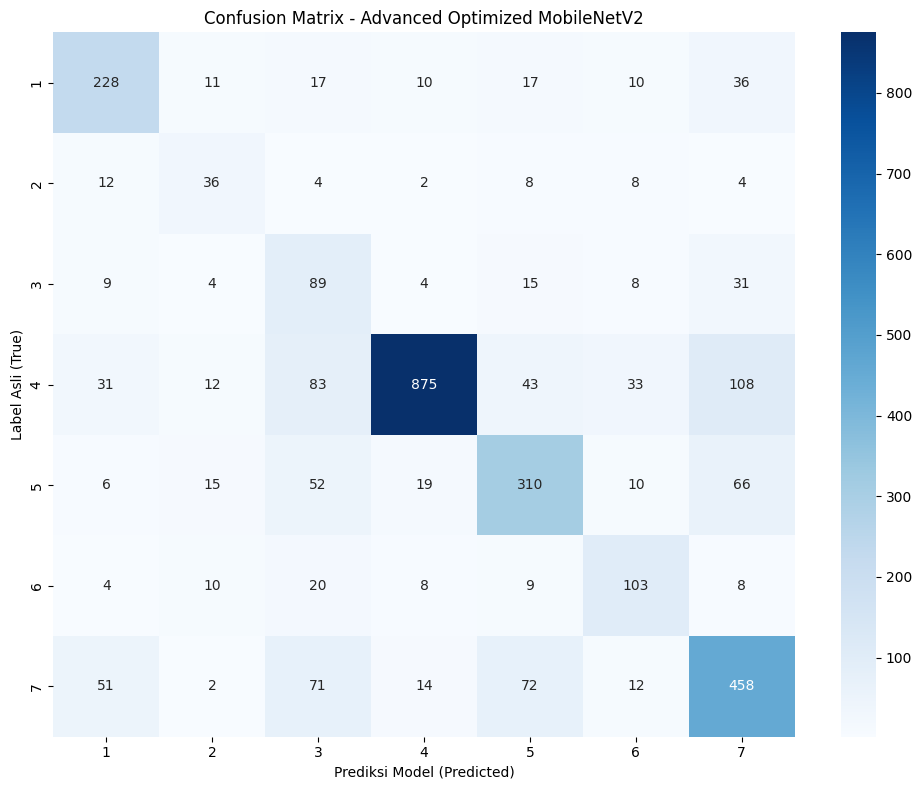

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix

print("Sedang melakukan inferensi pada data validasi dengan model terbaik...")
# Muat model terbaik yang disimpan (akan memiliki custom loss)
# Jika ada error saat load model karena custom loss, sertakan custom_objects
best_model = load_model(
    'samaya_rafdb_advanced.keras', 
    custom_objects={'CategoricalFocalCrossentropy': CategoricalFocalCrossentropy}
)

predictions = best_model.predict(val_ds, verbose=1)
y_pred = np.argmax(predictions, axis=1)

y_true = np.concatenate([y for x, y in val_ds], axis=0)
y_true = np.argmax(y_true, axis=1)

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Advanced Optimized MobileNetV2')
plt.ylabel('Label Asli (True)')
plt.xlabel('Prediksi Model (Predicted)')
plt.tight_layout()
plt.savefig('samaya_rafdb_confusion_matrix_advanced.png', dpi=300)
plt.show()